### Build A Basic Chatbot With Langgraph(Graph API Functionality)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]



In [5]:
import os
from dotenv import load_dotenv
load_dotenv()



True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

llm = ChatGroq(model="llama3-8b-8192")

llm.invoke([HumanMessage(content="Hello")])


APIConnectionError: Connection error.

In [5]:
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026688E130E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026688E13E00>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
## Node Functionality
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }


In [7]:
build_graph = StateGraph(State)

## Adding Node
build_graph.add_node("llmchatbot", chatbot)

## Ading Start Edge
build_graph.add_edge(START, "llmchatbot")
## Ading End Edge
build_graph.add_edge("llmchatbot", END)

## Compiling Graph
graph = build_graph.compile()

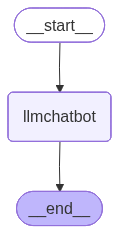

In [8]:
## Visualization of Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:

from langchain_core.messages import HumanMessage

respone = graph.invoke({
    "messages": [HumanMessage(content="Hi")]
})



APIConnectionError: Connection error.